In [341]:
import sys
import os
import pathlib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
# Get the absolute path to the 'python' directory (one level up from 'notebooks')
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)


In [342]:
from Utils.FilePaths import *
import pandas as pd

data_folder = DWD / "data_tables"

In [343]:
## Load files
files = list(Path.glob(data_folder, '*01975.csv'))
files

[PosixPath('/Users/jo/Documents/Ai_Engineering/Projects/Jo2Seb/files/data/lfs/DWD/data_tables/Hamburg-Fuhlsbüttel_01975.csv')]

In [344]:
## Load all weather data for Hamburg Fulsbüttel weather stations
df = pd.read_csv(files[0], index_col=0)
df.index = pd.to_datetime(df.index, utc=True)
df.head(5)

,precipitation,pressure_msl,sunshine,temperature,wind_direction,wind_speed,cloud_cover,dew_point,relative_humidity,visibility,wind_gust_direction,wind_gust_speed,precipitation_probability,precipitation_probability_6h,solar
datetime,,,,,,,,,,,,,,,
2018-01-01 00:00:00+00:00,0.3,993.8,NaN,8.2,210.0,13.0,100.0,7.8,97.0,900.0,210.0,19.8,NaN,NaN,0.0
2018-01-01 01:00:00+00:00,0.1,993.3,NaN,8.7,200.0,19.4,100.0,7.7,93.0,9000.0,220.0,38.9,NaN,NaN,0.0
2018-01-01 02:00:00+00:00,0.0,994.1,NaN,8.3,230.0,24.8,75.0,6.5,88.0,20000.0,250.0,40.7,NaN,NaN,0.0
2018-01-01 03:00:00+00:00,0.0,993.9,0.0,8.1,230.0,22.7,75.0,6.3,89.0,30000.0,200.0,37.1,NaN,NaN,0.0
2018-01-01 04:00:00+00:00,0.0,993.8,0.0,8.1,220.0,24.1,87.0,5.9,86.0,30000.0,220.0,37.1,NaN,NaN,0.0


<Axes: ylabel='datetime'>

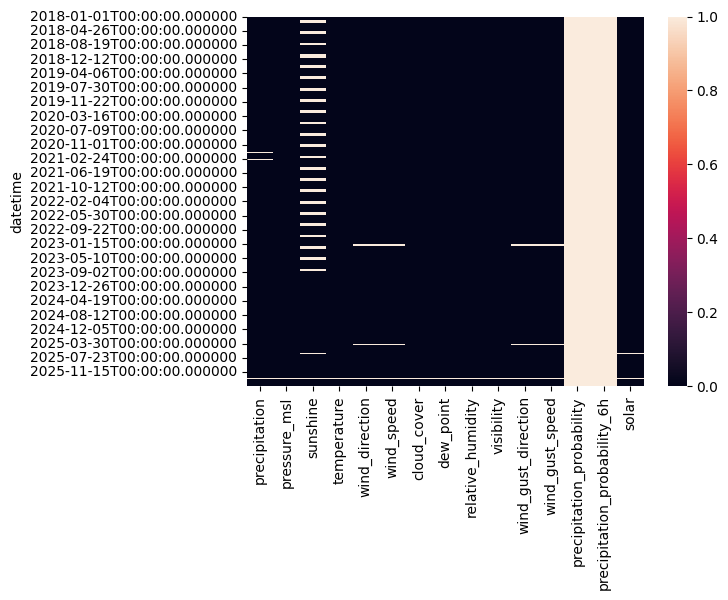

In [345]:
import seaborn as sns

mask =df.isna()
sns.heatmap(mask)

In [346]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
precipitation,71385.0,0.084972,0.474554,0.0,0.0,0.000,0.000,38.700
pressure_msl,71622.0,1014.882950,10.346613,974.2,1008.5,1015.500,1021.700,1048.200
sunshine,58550.0,14.554398,22.799532,0.0,0.0,0.000,28.000,60.000
temperature,71644.0,10.415553,7.281939,-13.8,5.1,10.000,15.700,38.400
wind_direction,71294.0,198.721351,89.978906,0.0,120.0,220.000,270.000,360.000
wind_speed,71175.0,14.582081,7.772548,0.0,8.6,13.700,19.400,60.100
cloud_cover,71463.0,69.852399,35.979471,0.0,37.0,87.000,100.000,100.000
dew_point,71617.0,6.390829,6.039277,-18.0,2.1,6.600,11.000,22.400
relative_humidity,71617.0,78.452253,16.445701,18.0,68.0,83.000,92.000,100.000
visibility,71463.0,30483.831073,17797.084257,40.0,15000.0,30000.000,45000.000,80000.000


In [347]:
## Missing data for wind measurements: 

            # --> Mostly direction is missing if wind speed is missing to

print("counts of no wind direction data:", len(df[df["wind_gust_direction"].isna()]))
print("counts of no wind speed data:", len(df[df["wind_gust_speed"].isna()]))
print("counts of no data for both at same time: :", len(df[df["wind_gust_speed"].isna() & df["wind_gust_direction"].isna()]))




counts of no wind direction data: 586
counts of no wind speed data: 574
counts of no data for both at same time: : 574


<Axes: ylabel='datetime'>

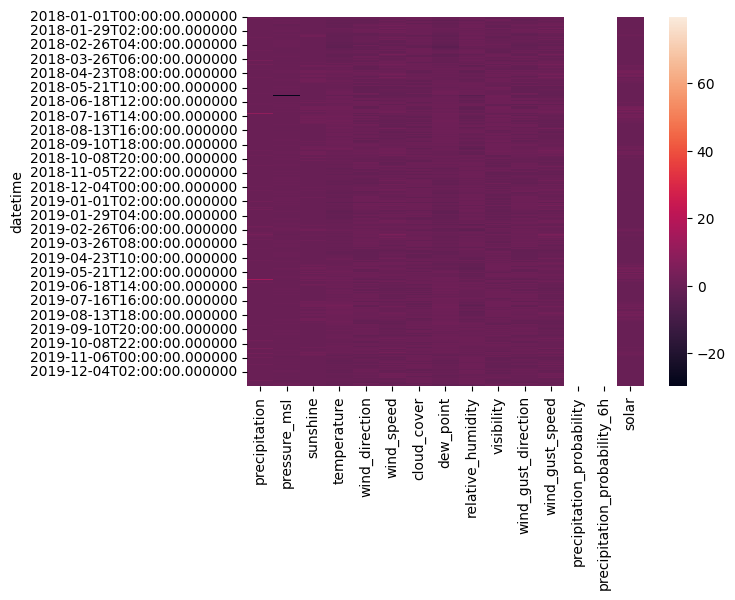

In [348]:
df_z = df.fillna(0)
df_z = df_z.loc["2018":"2019"]
df_z = (df_z - df_z.mean()) / df_z.std()   # per column
sns.heatmap(df_z)

In [349]:
df_z.describe().T

,count,mean,std,min,25%,50%,75%,max
precipitation,17520.0,3.244487e-18,1.0,-0.150026,-0.150026,-0.150026,-0.150026,79.838166
pressure_msl,17520.0,-2.592345e-15,1.0,-29.754322,-0.146748,0.049912,0.226026,0.886450
sunshine,17520.0,-6.488975e-18,1.0,-0.567281,-0.567281,-0.567281,0.128704,2.171022
temperature,17520.0,1.752023e-16,1.0,-3.079036,-0.729144,-0.063342,0.706900,3.174287
wind_direction,17520.0,1.297795e-17,1.0,-2.114220,-0.915062,0.284097,0.829169,1.810299
wind_speed,17520.0,-1.103126e-16,1.0,-1.864643,-0.723874,-0.128138,0.594349,4.701119
cloud_cover,17520.0,1.103126e-16,1.0,-1.892600,-0.817586,0.635134,0.635134,1.012841
dew_point,17520.0,-1.297795e-17,1.0,-3.955938,-0.710664,0.059679,0.764460,2.370707
relative_humidity,17520.0,1.946692e-16,1.0,-4.455033,-0.583066,0.238261,0.824923,1.411585
visibility,17520.0,1.168015e-16,1.0,-1.783127,-0.828153,0.126821,0.763470,3.310066


In [350]:
# Drop columns withouth information
df =df.drop(columns= ['precipitation_probability','precipitation_probability_6h'])

# NaN are at night --> replace with 0
df.loc[df["sunshine"].isna(), ['sunshine']] =0

df.loc[df["wind_direction"].isna(), ["wind_direction"]] = 0
df.loc[df["wind_direction"].isna(), ["wind_direction"]] = 0


# Also remove the rest of the NaN and replace with 0. --> this should later be imputed
df= df.fillna(0)



## Select only values from 2018-2027
df = df.loc['2018':'2025', :]

In [351]:
df.head()

,precipitation,pressure_msl,sunshine,temperature,wind_direction,wind_speed,cloud_cover,dew_point,relative_humidity,visibility,wind_gust_direction,wind_gust_speed,solar
datetime,,,,,,,,,,,,,
2018-01-01 00:00:00+00:00,0.3,993.8,0.0,8.2,210.0,13.0,100.0,7.8,97.0,900.0,210.0,19.8,0.0
2018-01-01 01:00:00+00:00,0.1,993.3,0.0,8.7,200.0,19.4,100.0,7.7,93.0,9000.0,220.0,38.9,0.0
2018-01-01 02:00:00+00:00,0.0,994.1,0.0,8.3,230.0,24.8,75.0,6.5,88.0,20000.0,250.0,40.7,0.0
2018-01-01 03:00:00+00:00,0.0,993.9,0.0,8.1,230.0,22.7,75.0,6.3,89.0,30000.0,200.0,37.1,0.0
2018-01-01 04:00:00+00:00,0.0,993.8,0.0,8.1,220.0,24.1,87.0,5.9,86.0,30000.0,220.0,37.1,0.0


Text(0, 0.5, 'Wind Velocity [m/s]')

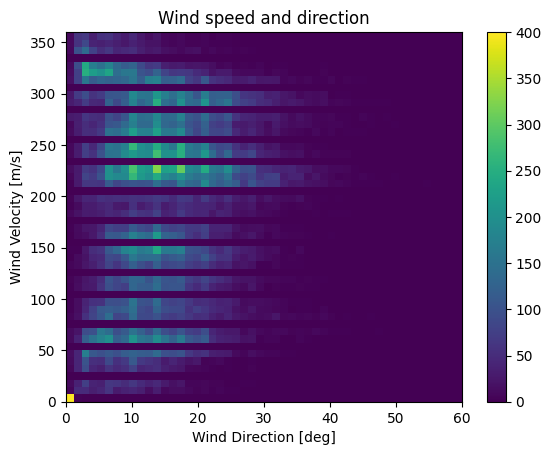

In [352]:
plt.hist2d(df['wind_speed'], df['wind_direction'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.title("Wind speed and direction")
plt.xlabel('Wind Direction [deg]')
plt.ylabel('Wind Velocity [m/s]')

Text(0, 0.5, 'Wind Gust Velocity [m/s]')

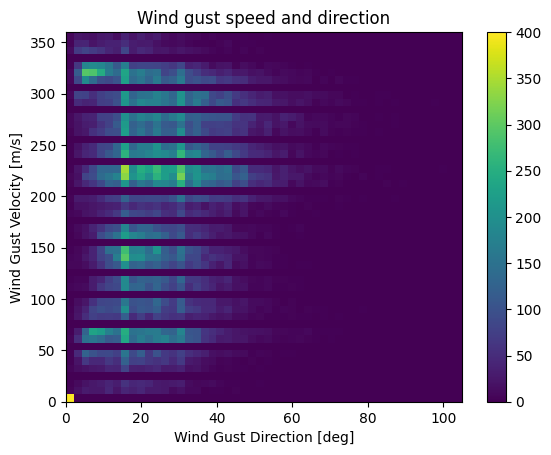

In [353]:
plt.hist2d(df['wind_gust_speed'], df['wind_gust_direction'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.title("Wind gust speed and direction")
plt.xlabel('Wind Gust Direction [deg]')
plt.ylabel('Wind Gust Velocity [m/s]')

In [354]:
## Convert wind speed and direction to vector

wv = df.pop('wind_speed')  # wind velocity
wgv =df.pop('wind_gust_speed') # wind gust velocity

wd_deg = df.pop("wind_direction") # wind direction
wgd_deg = df.pop("wind_gust_direction") # wind direction

wd_rad =  wd_deg * np.pi / 180 # convert degree to radians
wgd_rad = wgd_deg * np.pi / 180 

##### create vectors and add back to df

# Calculate the wind x and y components.
df['w_x'] = wv*np.cos(wd_rad)
df['w_y'] = wv*np.sin(wd_rad)

# Calculate the wind gust x and y components.
df['wg_x'] = wgv*np.cos(wgd_rad)
df['wg_y'] = wgv*np.sin(wgd_rad)

Text(0, 0.5, 'Wind vector y-component')

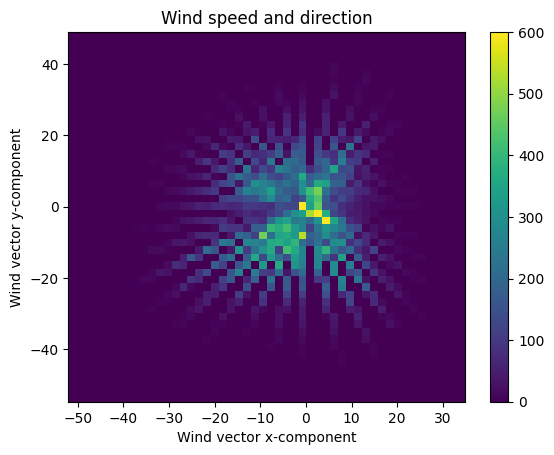

In [355]:
plt.hist2d(df['w_x'],df['w_y'], bins=(50, 50), vmax= 600 )
plt.colorbar()
plt.title("Wind speed and direction")
plt.xlabel('Wind vector x-component')
plt.ylabel('Wind vector y-component')

Text(0, 0.5, 'Wind vector y-component')

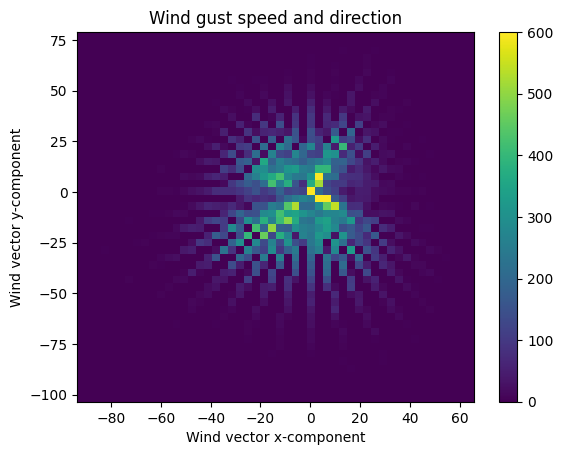

In [356]:
plt.hist2d(df['wg_x'],df['wg_y'], bins=(50, 50), vmax= 600 )
plt.colorbar()
plt.title("Wind gust speed and direction")
plt.xlabel('Wind vector x-component')
plt.ylabel('Wind vector y-component')

In [359]:
def plot_fourier(data_series: pd.Series, save_fig: bool = False, safe_path = pathlib.Path("")):
    
    
    fft = tf.signal.rfft(data_series)

    f_per_dataset = np.arange(0, len(fft))

    n_samples_h = len(data_series)
    hours_per_year = 24*365.2524
    years_per_dataset = n_samples_h/(hours_per_year)

    f_per_year = f_per_dataset/years_per_dataset
    
    plt.figure()
    plt.step(f_per_year, np.abs(fft))
    plt.title(data_series.name)
    plt.xscale('log')
    #plt.ylim(0, 400000)
    plt.xlim([0.1, max(plt.xlim())])
    plt.xticks([0.25, 1,30, 365.2524], labels=['1/4years','1/Year', '1/month', '1/day'])
    _ = plt.xlabel('Frequency (log scale)')

    if not save_fig:
        plt.show()
    elif save_fig:
        file_name = data_series.name + ".pdf"
        file_path = safe_path / file_name
        plt.savefig(file_path)
        plt.close()

In [360]:
## Plot the seasonality of all columns
safe_path = DWD / "graphs"
for col in df.columns:
    data_series = df.loc[:, col]
    plot_fourier(data_series, save_fig=True, safe_path=safe_path)